In [10]:
import pickle
import behavior.boris_extraction as boris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import sem
from itertools import combinations
import pandas as pd
import os
def hex_2_rgb(hex_color): # Orange color
    rgb_color = tuple(int(hex_color[i:i+2], 16) / 255.0 for i in (1, 3, 5))
    return rgb_color

def pickle_this(thing_to_pickle, file_name):
    """
    Pickles things
    Args (2):   
        thing_to_pickle: anything you want to pickle
        file_name: str, filename that ends with .pkl 
    Returns:
        none
    """
    with open(file_name,'wb') as file:
        pickle.dump(thing_to_pickle, file)

def unpickle_this(pickle_file):
    """
    Unpickles things
    Args (1):   
        file_name: str, pickle filename that already exists and ends with .pkl
    Returns:
        pickled item
    """
    with open(pickle_file, 'rb') as file:
        return(pickle.load(file))
    
cup_agent_mapping = pd.read_excel(r"C:\Users\megha\Documents\GitHub\diff_fam_social_memory_ephys\albert_cups\Social_Pref_Cup_Assignments.xlsx")
cup_agent_mapping 

,Subject,sniff cup 1,sniff cup 2,sniff cup 3,sniff cup 4
0,nn1,nothing,novel,short_term,long_term
1,nn2,long_term,nothing,novel,short_term
2,nn5,nothing,long_term,short_term,novel
3,nn6,novel,nothing,long_term,short_term
4,pp1,nothing,novel,short_term,long_term
5,pp2,long_term,nothing,novel,short_term
6,pp5,nothing,long_term,short_term,novel
7,pp6,novel,nothing,long_term,short_term
8,pp3,short_term,long_term,nothing,novel
9,pp4,novel,short_term,long_term,nothing


In [11]:
cohort1_boris = r"C:\Users\megha\UF Dropbox\Meghan Cum\Padilla-Coreano Lab\2025\Photometry Pilot 2\Cohort 1\FP2_Manual_Annotations\C1_Social_Pref"
cohort2_boris = r"C:\Users\megha\UF Dropbox\Meghan Cum\Padilla-Coreano Lab\2025\Photometry Pilot 2\Cohort 2\P2C2_Manual_Annotations\Aggregated_Events\C2_Social_Pref"
cohort3_boris = r"C:\Users\megha\UF Dropbox\Meghan Cum\Padilla-Coreano Lab\2025\Photometry Pilot 2\Cohort 3\P2C3_Manual_Annotations\Social Preference"

In [12]:
CUP_MAP_PATH = r"C:\Users\megha\Documents\GitHub\diff_fam_social_memory_ephys\albert_cups\Social_Pref_Cup_Assignments.xlsx"

# subject value in the Boris 'Subject' column differs by cohort
SUBJECT_LABEL = {
    cohort1_boris: "Subject",
    cohort2_boris: "Subject",
    cohort3_boris: "No focal subject",
}

# ── build subject_id → (csv_path, subject_label) — detect label per file ──────                                                                                                                                         
def get_subject_label(csv_path):                                                                                                                                                                                           
    """detect the focal subject label used in this Boris CSV"""                                                                                                                                                          
    df = pd.read_csv(csv_path, usecols=["Subject"])                                                                                                                                                                      
    subjects = df["Subject"].unique()
    # prefer 'No focal subject' > 'Subject' > whatever else is there
    for candidate in ["No focal subject", "Subject"]:
        if candidate in subjects:
            return candidate
    return subjects[0]  # fallback

subject_to_file = {}
for cohort_dir in [cohort3_boris, cohort2_boris, cohort1_boris]:
    for fname in os.listdir(cohort_dir):
        if fname.endswith(".csv"):
            subject_id = fname.split("-")[0]
            path = os.path.join(cohort_dir, fname)
            subject_to_file[subject_id] = {
                "path": path,
                "subject_label": get_subject_label(path),
            }

# verify
for subj, info in subject_to_file.items():
    print(f"{subj:<10} label={info['subject_label']:<20} {info['path'].split(os.sep)[-1]}")

# ── load cup assignment map ────────────────────────────────────────────────────
cup_map_df = pd.read_excel(CUP_MAP_PATH)                                                                                                                                                                                   
cup_map_df.columns = ["subject", "cup_1", "cup_2", "cup_3", "cup_4"]
cup_map_df = cup_map_df.applymap(lambda x: x.strip() if isinstance(x, str) else x)  
# rename columns to be consistent: Subject, cup_1, cup_2, cup_3, cup_4
cup_map_df.columns = ["subject", "cup_1", "cup_2", "cup_3", "cup_4"]

# ── print subject → csv path ───────────────────────────────────────────────────
print(f"{'Subject':<10} {'CSV Path'}")
print("-" * 90)
for _, row in cup_map_df.iterrows():
    subj = row["subject"]
    info = subject_to_file.get(subj)
    if info:
        print(f"{subj:<10} {info['path']}")
    else:
        print(f"{subj:<10} *** NOT FOUND ***")

nn1        label=No focal subject     nn1-250117-081652 - Social_mem_cups.csv
nn2        label=No focal subject     nn2-250117-085631 - Social_mem_cups.csv
nn3        label=No focal subject     nn3-250118-090940 - Social_mem_cups.csv
nn4        label=No focal subject     nn4-250118-094351 - Social_mem_cups.csv
nn5        label=Subject              nn5-250117-093631.csv
nn6        label=Subject              nn6-250117-101903.csv
nn7        label=Subject              nn7-250118-101917.csv
nn8        label=Subject              nn8-250118-105443.csv
pp1        label=No focal subject     pp1-250117-110456 - Social_mem_cups.csv
pp2        label=No focal subject     pp2-250117-113909 - Social_mem_cups.csv
pp3        label=No focal subject     pp3-250118-064713 - Social_mem_cups.csv
pp4        label=No focal subject     pp4-250118-072201 - Social_mem_cups.csv
pp5        label=Subject              pp5-250117-121543.csv
pp6        label=Subject              pp6-250117-124823.csv
pp7        label

C:\Users\megha\AppData\Local\Temp\ipykernel_19492\1035492012.py:39: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  cup_map_df = cup_map_df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


In [13]:
AGENT_MAP = {                                                                                                                                                                                                              
    "nothing":    "empty",                                                                                                                                                                                               
    "short_term": "familiar",
    "long_term":  "cagemate",
    "novel":      "novel",
}

print(f"{'Subject':<10} {'intro':>6} {'remove':>7}  bouts per cup (agent)")
print("-" * 80)
for _, row in cup_map_df.iterrows():
    subj = row["subject"]
    if subj not in subject_to_file:
        continue
    df = pd.read_csv(subject_to_file[subj]["path"])

    intro_events  = ["Subject Introduced", "mouse in"]
    remove_events = ["Subject Removed",    "mouse out"]
    intro_count  = df[df["Behavior"].isin(intro_events)].shape[0]
    remove_count = df[df["Behavior"].isin(remove_events)].shape[0]

    cup_summary = []
    for cup_num in [1, 2, 3, 4]:
        agent = AGENT_MAP[row[f"cup_{cup_num}"]]
        behaviors = [f"sniff cup {cup_num}", f"chew cup {cup_num}"]
        count = df[df["Behavior"].isin(behaviors)].shape[0]
        cup_summary.append(f"cup{cup_num}={agent}({count})")

    print(f"{subj:<10} {intro_count:>6} {remove_count:>7}  {', '.join(cup_summary)}")

Subject     intro  remove  bouts per cup (agent)
--------------------------------------------------------------------------------
nn1             1       0  cup1=empty(24), cup2=novel(14), cup3=familiar(6), cup4=cagemate(2)
nn2             1       0  cup1=cagemate(17), cup2=empty(17), cup3=novel(23), cup4=familiar(25)
nn5             1       0  cup1=empty(14), cup2=cagemate(10), cup3=familiar(12), cup4=novel(31)
nn6             1       0  cup1=novel(13), cup2=empty(7), cup3=cagemate(16), cup4=familiar(6)
pp1             1       0  cup1=empty(10), cup2=novel(20), cup3=familiar(14), cup4=cagemate(17)
pp2             1       0  cup1=cagemate(14), cup2=empty(15), cup3=novel(21), cup4=familiar(14)
pp5             1       0  cup1=empty(15), cup2=cagemate(27), cup3=familiar(18), cup4=novel(28)
pp6             1       0  cup1=novel(19), cup2=empty(19), cup3=cagemate(15), cup4=familiar(12)
pp3             1       0  cup1=familiar(4), cup2=cagemate(25), cup3=empty(12), cup4=novel(5)
pp4         

In [14]:
behavior_dicts = {}

for _, row in cup_map_df.iterrows():
    subj = row["subject"]
    if subj not in subject_to_file:
        continue
    info = subject_to_file[subj]
    df = pd.read_csv(info["path"])
    subject_label = info["subject_label"]

    agent_bouts = {}
    for cup_num in [1, 2, 3, 4]:
        agent = AGENT_MAP[row[f"cup_{cup_num}"]]
        behaviors = [f"sniff cup {cup_num}", f"chew cup {cup_num}"]
        bouts = boris.get_behavior_bouts(df, [subject_label], behaviors, min_iti = 1, min_bout = 0.5)
        # if agent already seen (shouldn't happen, but just in case)
        if agent in agent_bouts:
            agent_bouts[agent] = np.vstack([agent_bouts[agent], bouts]) if bouts.size > 0 else agent_bouts[agent]
        else:
            agent_bouts[agent] = bouts

    behavior_dicts[subj] = agent_bouts
    print(f"{subj}: { {k: v.shape[0] for k, v in agent_bouts.items()} }")

nn1: {'empty': 23, 'novel': 11, 'familiar': 5, 'cagemate': 2}
nn2: {'cagemate': 15, 'empty': 13, 'novel': 19, 'familiar': 20}
nn5: {'empty': 12, 'cagemate': 8, 'familiar': 9, 'novel': 23}
nn6: {'novel': 9, 'empty': 6, 'cagemate': 12, 'familiar': 5}
pp1: {'empty': 10, 'novel': 17, 'familiar': 13, 'cagemate': 16}
pp2: {'cagemate': 12, 'empty': 15, 'novel': 17, 'familiar': 13}
pp5: {'empty': 13, 'cagemate': 24, 'familiar': 16, 'novel': 21}
pp6: {'novel': 17, 'empty': 15, 'cagemate': 12, 'familiar': 10}
pp3: {'familiar': 4, 'cagemate': 23, 'empty': 7, 'novel': 4}
pp4: {'novel': 13, 'familiar': 15, 'cagemate': 19, 'empty': 16}
pp7: {'familiar': 18, 'novel': 25, 'empty': 21, 'cagemate': 14}
pp8: {'cagemate': 17, 'familiar': 11, 'novel': 20, 'empty': 10}
nn3: {'familiar': 15, 'cagemate': 21, 'empty': 13, 'novel': 16}
nn4: {'novel': 13, 'familiar': 12, 'cagemate': 12, 'empty': 22}
nn7: {'familiar': 14, 'novel': 11, 'empty': 9, 'cagemate': 6}
nn8: {'cagemate': 12, 'familiar': 17, 'novel': 8, 'e

         novel  familiar  cagemate
subject                           
nn1     -0.186    -0.419    -0.796
nn2      0.265     0.284    -0.126
nn5      0.589     0.249    -0.277
nn6      0.164     0.066     0.284
pp1      0.558     0.297     0.244
pp2      0.649     0.070     0.254
pp5      0.315    -0.038     0.209
pp6      0.427    -0.272    -0.118
pp3     -0.388    -0.606     0.215
pp4      0.346     0.058     0.103
pp7      0.310    -0.015    -0.190
pp8      0.643     0.362     0.366
nn3     -0.094     0.066    -0.009
nn4      0.189    -0.257    -0.138
nn7      0.249     0.319     0.048
nn8      0.182     0.381     0.116
n5      -0.144     0.144     0.601
p5       0.064     0.094     0.504
n6       0.068     0.365    -0.004
p7       0.073     0.003     0.252
p6       0.255    -0.336    -0.076
n7       0.145     0.077     0.452
p8      -0.185    -0.097    -0.363
n1       0.234     0.089     0.451
p1      -0.148    -0.107    -0.377
n2      -0.123    -0.059     0.322
p3       0.181     0

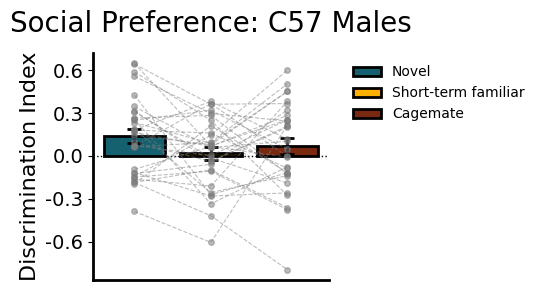

In [35]:
from scipy.stats import ttest_rel, sem                                                                                                                                                                                     
from statsmodels.stats.multitest import multipletests                                                                                                                                                                      
from itertools import combinations       
import matplotlib.ticker as ticker                                                                                                                                                                                  
                                                                                                                                                                                                                            
def discrimination_index(agent_time, empty_time):
    denom = agent_time + empty_time
    return (agent_time - empty_time) / denom if denom > 0 else np.nan

def total_time_s(bouts):
    if bouts.size == 0:
        return 0.0
    return np.sum(bouts[:, 1] - bouts[:, 0]) / 1000

# ── compute DI per subject ─────────────────────────────────────────────────────
agents = ["novel", "familiar", "cagemate"]
rows = []
for subj, agent_bouts in behavior_dicts.items():
    empty_time = total_time_s(agent_bouts["empty"])
    row = {"subject": subj}
    for agent in agents:
        row[agent] = discrimination_index(total_time_s(agent_bouts[agent]), empty_time)
    rows.append(row)

di_df = pd.DataFrame(rows).set_index("subject")
print(di_df.round(3))

# ── pairwise paired t-tests with Holm-Bonferroni ──────────────────────────────
pairs = list(combinations(agents, 2))
t_stats, p_values = [], []
for a1, a2 in pairs:
    t, p = ttest_rel(di_df[a1].dropna(), di_df[a2].dropna())
    t_stats.append(t); p_values.append(p)

_, p_corrected, _, _ = multipletests(p_values, method="holm")
print("\nPairwise t-tests (Holm-corrected):")
for (a1, a2), t, p_raw, p_holm in zip(pairs, t_stats, p_values, p_corrected):
    print(f"  {a1} vs {a2}: t={t:.3f}, p_raw={p_raw:.4f}, p_holm={p_holm:.4f}")

# ── plot ───────────────────────────────────────────────────────────────────────
plt.rcParams.update({"font.weight": "bold", "axes.titleweight": "bold", "axes.labelweight": "bold"})

color_dict = {
    "novel":    hex_2_rgb("#15616F"),
    "familiar": (1.0, 0.6862745098039216, 0.0),
    "cagemate": hex_2_rgb("#792910"),
}

avgs     = [di_df[a].mean() for a in agents]
sems     = [sem(di_df[a].dropna()) for a in agents]
data_arr = di_df[agents].values.T  # (3, n_subjects)

fig, ax = plt.subplots(figsize=(5.5, 3))
x = np.arange(len(agents))

ax.bar(x, avgs, yerr=sems,
        color=list(color_dict.values()),
        edgecolor="black", linewidth=2,
        capsize=5, error_kw={"elinewidth": 2, "capthick": 2})

for j in range(data_arr.shape[1]):
    ax.plot(x, data_arr[:, j], color="#7d7d7d", linestyle="--",
            marker="o", markersize=4, linewidth=0.8, alpha = 0.5, zorder=4)

ax.axhline(0, color="black", linewidth=1, linestyle=":")

ax.set_xticks([])
ax.tick_params(labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('normal')
#ax.set_xticklabels(["Novel", "Familiar", "Cagemate"], fontsize=13)
ax.set_ylabel("Discrimination Index", fontsize=16, fontweight = 'normal')
ax.set_title("Social Preference: C57 Males", fontsize=20, pad=15, fontweight = 'normal')
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.tick_params(labelsize=14)
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor=color_dict['novel'], edgecolor='black', linewidth=2, label='Novel'),
    plt.Rectangle((0, 0), 1, 1, facecolor=color_dict['familiar'], edgecolor='black', linewidth=2, label='Short-term familiar'),
    plt.Rectangle((0, 0), 1, 1, facecolor=color_dict['cagemate'], edgecolor='black', linewidth=2, label='Cagemate'),
]
leg = plt.legend(handles=legend_elements, fontsize=10, frameon=False, loc='best', bbox_to_anchor=(1.05, 1))
for text in leg.get_texts():
    text.set_fontweight('normal')
plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.3))
plt.tight_layout()
plt.savefig("albert_cups/DI_social_pref_c57.pdf", bbox_inches="tight", dpi=600)

plt.show()


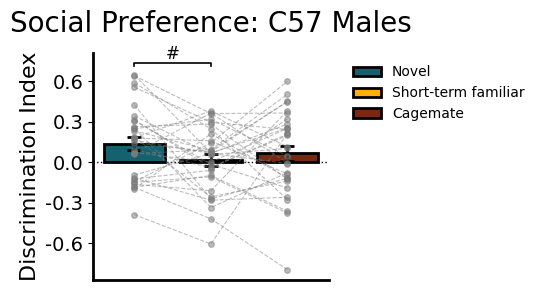

In [40]:
# ── significance stars helper ──────────────────────────────────────────────────
def p_to_stars(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    elif p < 0.1: return "#"
    else: return "ns"

# ── plot ───────────────────────────────────────────────────────────────────────
plt.rcParams.update({"font.weight": "bold", "axes.titleweight": "bold", "axes.labelweight": "bold"})

color_dict = {
    "novel":    hex_2_rgb("#15616F"),
    "familiar": (1.0, 0.6862745098039216, 0.0),
    "cagemate": hex_2_rgb("#792910"),
}
agents = ["novel", "familiar", "cagemate"]
avgs     = [di_df[a].mean() for a in agents]
sems     = [sem(di_df[a].dropna()) for a in agents]
data_arr = di_df[agents].values.T  # (3, n_subjects)

fig, ax = plt.subplots(figsize=(5.5, 3))
x = np.arange(len(agents))

ax.bar(x, avgs, yerr=sems,
        color=list(color_dict.values()),
        edgecolor="black", linewidth=2,
        capsize=5, error_kw={"elinewidth": 2, "capthick": 2})

for j in range(data_arr.shape[1]):
    ax.plot(x, data_arr[:, j], color="#7d7d7d", linestyle="--",
            marker="o", markersize=4, linewidth=0.8, alpha=0.5, zorder=4)

ax.axhline(0, color="black", linewidth=1, linestyle=":")

# ── add significance brackets ──────────────────────────────────────────────────
def add_bracket(ax, x1, x2, y, stars, bracket_height=0.02):
    ax.plot([x1, x1, x2, x2], [y, y + bracket_height, y + bracket_height, y],
            color="black", linewidth=1.2)
    ax.text((x1 + x2) / 2, y + bracket_height, stars,
            ha="center", va="bottom", fontsize=12, fontweight="normal")

# build bracket heights — stack them so they don't overlap
y_max = max(a + s for a, s in zip(avgs, sems)) + 0.45
gap = 0.08  # vertical space between brackets

for i, ((a1, a2), p_holm) in enumerate(zip(pairs, p_corrected)):
    stars = p_to_stars(p_holm)
    if stars == "ns":
        continue
    x1, x2 = agents.index(a1), agents.index(a2)
    y = y_max + gap * (i + 1)
    add_bracket(ax, x1, x2, y, stars)

# ── axes formatting ────────────────────────────────────────────────────────────
ax.set_xticks([])
ax.tick_params(labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('normal')
ax.set_ylabel("Discrimination Index", fontsize=16, fontweight='normal')
ax.set_title("Social Preference: C57 Males", fontsize=20, pad=15, fontweight='normal')
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.tick_params(labelsize=14)

legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor=color_dict['novel'], edgecolor='black', linewidth=2, label='Novel'),
    plt.Rectangle((0, 0), 1, 1, facecolor=color_dict['familiar'], edgecolor='black', linewidth=2, label='Short-term familiar'),
    plt.Rectangle((0, 0), 1, 1, facecolor=color_dict['cagemate'], edgecolor='black', linewidth=2, label='Cagemate'),
]
leg = plt.legend(handles=legend_elements, fontsize=10, frameon=False, loc='best', bbox_to_anchor=(1.05, 1))
for text in leg.get_texts():
    text.set_fontweight('normal')

ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.3))
plt.tight_layout()
plt.savefig("albert_cups/DI_social_pref_c57_trending.pdf", bbox_inches="tight", dpi=600)
plt.show()

In [17]:
rank_data = pd.read_csv(r'C:\Users\megha\Documents\GitHub\diff_fam_social_memory_ephys\albert_cups\reward_competition_davids_score_ranks(in).csv')
rank_data['subject'] = rank_data['ID']
rank_data = rank_data.drop(['ID'], axis=1)
rank_data

,DS,Cage,Rank,subject
0,3.263158,n1,1,n3
1,0.315789,n1,2,n4
2,-0.739850,n1,3,n2
3,-2.839098,n1,4,n1
4,2.643609,n2,1,n5
5,0.282707,n2,2,n6
6,-0.331721,n2,3,n7
7,2.973934,nn1,1,nn4
8,0.497076,nn1,2,nn2
9,-1.503268,nn1,3,nn3


In [18]:
di_df

,novel,familiar,cagemate
subject,,,
nn1,-0.185819,-0.419166,-0.796296
nn2,0.264806,0.283820,-0.126173
nn5,0.588872,0.248588,-0.276800
nn6,0.164129,0.066163,0.284058
pp1,0.557736,0.297362,0.243871
pp2,0.648975,0.069638,0.253631
pp5,0.315359,-0.038414,0.208687
pp6,0.426617,-0.271724,-0.117576
pp3,-0.387978,-0.605563,0.214595


In [19]:
rank_pref_data = di_df.merge(rank_data, on='subject')

Pearson r = 0.105, p = 0.573


Text(0.5, 1.0, 'r = 0.105, p = 0.573')

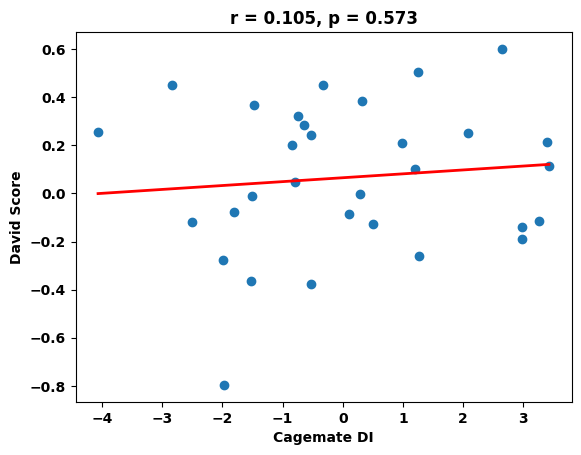

In [20]:
from scipy import stats
import numpy as np

x = rank_pref_data['DS']
y = rank_pref_data['cagemate']

# Pearson correlation
r, p = stats.pearsonr(x, y)
print(f"Pearson r = {r:.3f}, p = {p:.3f}")

# Linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

# Plot
plt.scatter(x, y)
plt.plot(x_line, y_line, color='red', linewidth=2)
plt.ylabel('David Score')
plt.xlabel('Cagemate DI')
plt.title(f'r = {r:.3f}, p = {p:.3f}')

In [21]:
# ── Shapiro-Wilk normality test ───────────────────────────────────────────────                                                                                                                                                                                                                                        
from scipy.stats import shapiro
                                                                                                                                                                                                                                                                                                                        
print("Shapiro-Wilk normality test:")                                                                                                                                                                                                                                                                                 
for agent in agents:                                                                                                                                                                                                                                                                                                    
    data = di_df[agent].dropna()
    stat, p = shapiro(data)
    print(f"  {agent}: W={stat:.4f}, p={p:.4f} {'(normal)' if p > 0.05 else '(non-normal)'}")

print("Shapiro-Wilk on pairwise DI differences:")
for a1, a2 in pairs:
    diff = di_df[a1].dropna() - di_df[a2].dropna()
    stat, p = shapiro(diff)
    print(f"  {a1} - {a2}: W={stat:.4f}, p={p:.4f} {'(normal)' if p > 0.05 else '(non-normal)'}")

Shapiro-Wilk normality test:
  novel: W=0.9593, p=0.2796 (normal)
  familiar: W=0.9609, p=0.3080 (normal)
  cagemate: W=0.9684, p=0.4768 (normal)
Shapiro-Wilk on pairwise DI differences:
  novel - familiar: W=0.9875, p=0.9688 (normal)
  novel - cagemate: W=0.9779, p=0.7513 (normal)
  familiar - cagemate: W=0.9661, p=0.4196 (normal)


In [22]:
cd1_female_data = pd.read_excel(r'C:\Users\megha\Documents\GitHub\diff_fam_social_memory_ephys\albert_cups\Social Memory CD1 F 4 Cups Data.xlsx')
cd1_female_data.drop(['Unnamed: 1'], axis=1, inplace=True)
cd1_female_data = cd1_female_data[cd1_female_data['Subjects'].apply(lambda x: isinstance(x, float))]
cd1_female_data = cd1_female_data[cd1_female_data['Subjects'].apply(lambda x: ~np.isnan(x))]
print(cd1_female_data)

   Subjects Cagemate  Familiar    Novel    Empty
0       7.1    19.792  139.085    67.39   81.567
1       7.2   188.539   51.583  233.404    9.808
2       7.3    37.136   56.512  318.392   26.464
3       7.4    39.472  101.296  260.336   11.056
4       8.1    72.178   45.391  121.423   44.302
5       8.2    50.635   28.863    409.9    8.384
6       8.3     84.09  185.111   89.138  113.145
7       8.4   293.309   77.486   56.493   53.278
8       9.1     92.67   59.919  212.646   50.623
9       9.2    88.384   50.014   80.494   55.296
10      9.3   212.478   72.126  103.981   486.32
11      9.4   372.358   38.335   69.263    7.136


In [23]:
print(cd1_female_data.columns)

Index(['Subjects', 'Cagemate ', 'Familiar', 'Novel', 'Empty'], dtype='object')


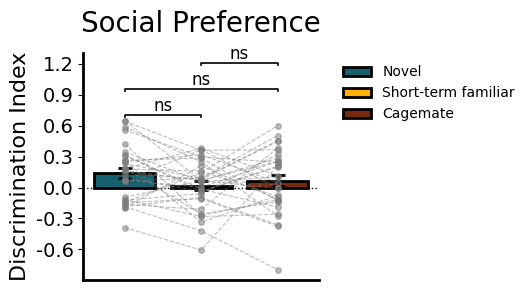

In [24]:
# ── significance stars helper ──────────────────────────────────────────────────
def p_to_stars(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

# ── plot ───────────────────────────────────────────────────────────────────────
plt.rcParams.update({"font.weight": "bold", "axes.titleweight": "bold", "axes.labelweight": "bold"})

color_dict = {
    "novel":    hex_2_rgb("#15616F"),
    "familiar": (1.0, 0.6862745098039216, 0.0),
    "cagemate": hex_2_rgb("#792910"),
}

avgs     = [di_df[a].mean() for a in agents]
sems     = [sem(di_df[a].dropna()) for a in agents]
data_arr = di_df[agents].values.T  # (3, n_subjects)

fig, ax = plt.subplots(figsize=(5.5, 3))
x = np.arange(len(agents))

ax.bar(x, avgs, yerr=sems,
        color=list(color_dict.values()),
        edgecolor="black", linewidth=2,
        capsize=5, error_kw={"elinewidth": 2, "capthick": 2})

for j in range(data_arr.shape[1]):
    ax.plot(x, data_arr[:, j], color="#7d7d7d", linestyle="--",
            marker="o", markersize=4, linewidth=0.8, alpha=0.5, zorder=4)

ax.axhline(0, color="black", linewidth=1, linestyle=":")

# ── add significance brackets ──────────────────────────────────────────────────
def add_bracket(ax, x1, x2, y, stars, bracket_height=0.02):
    ax.plot([x1, x1, x2, x2], [y, y + bracket_height, y + bracket_height, y],
            color="black", linewidth=1.2)
    ax.text((x1 + x2) / 2, y + bracket_height, stars,
            ha="center", va="bottom", fontsize=12, fontweight="normal")

# build bracket heights — stack them so they don't overlap
y_max = max(a + s for a, s in zip(avgs, sems)) + 0.25
gap = 0.25  # vertical space between brackets

for i, ((a1, a2), p_holm) in enumerate(zip(pairs, p_corrected)):
    stars = p_to_stars(p_holm)
    x1, x2 = agents.index(a1), agents.index(a2)
    y = y_max + gap * (i + 1)
    add_bracket(ax, x1, x2, y, stars)

# ── axes formatting ────────────────────────────────────────────────────────────
ax.set_xticks([])
ax.tick_params(labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('normal')
ax.set_ylabel("Discrimination Index", fontsize=16, fontweight='normal')
ax.set_title("Social Preference", fontsize=20, pad=15, fontweight='normal')
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.tick_params(labelsize=14)

legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor=color_dict['novel'], edgecolor='black', linewidth=2, label='Novel'),
    plt.Rectangle((0, 0), 1, 1, facecolor=color_dict['familiar'], edgecolor='black', linewidth=2, label='Short-term familiar'),
    plt.Rectangle((0, 0), 1, 1, facecolor=color_dict['cagemate'], edgecolor='black', linewidth=2, label='Cagemate'),
]
leg = plt.legend(handles=legend_elements, fontsize=10, frameon=False, loc='best', bbox_to_anchor=(1.05, 1))
for text in leg.get_texts():
    text.set_fontweight('normal')

ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.3))
plt.tight_layout()
plt.savefig("albert_cups/DI_social_pref_cd1_males.pdf", bbox_inches="tight", dpi=600)
plt.show()

Novel
0    67.39
Name: Novel, dtype: object
81.567
Familiar
0    139.085
Name: Familiar, dtype: object
81.567
Cagemate 
0    19.792
Name: Cagemate , dtype: object
81.567
Novel
1    233.404
Name: Novel, dtype: object
9.808
Familiar
1    51.583
Name: Familiar, dtype: object
9.808
Cagemate 
1    188.539
Name: Cagemate , dtype: object
9.808
Novel
2    318.392
Name: Novel, dtype: object
26.464
Familiar
2    56.512
Name: Familiar, dtype: object
26.464
Cagemate 
2    37.136
Name: Cagemate , dtype: object
26.464
Novel
3    260.336
Name: Novel, dtype: object
11.056
Familiar
3    101.296
Name: Familiar, dtype: object
11.056
Cagemate 
3    39.472
Name: Cagemate , dtype: object
11.056
Novel
4    121.423
Name: Novel, dtype: object
44.302
Familiar
4    45.391
Name: Familiar, dtype: object
44.302
Cagemate 
4    72.178
Name: Cagemate , dtype: object
44.302
Novel
5    409.9
Name: Novel, dtype: object
8.384
Familiar
5    28.863
Name: Familiar, dtype: object
8.384
Cagemate 
5    50.635
Name: Cagemate , d

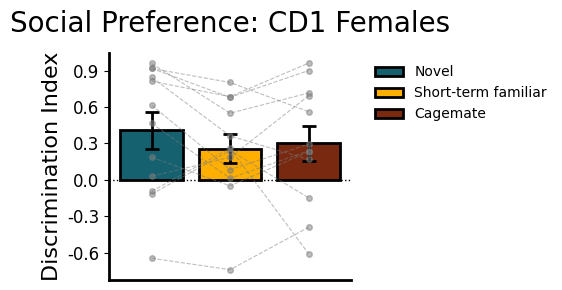

In [32]:
                                                                                                                                                                                        


# ── compute DI per subject ─────────────────────────────────────────────────────
agents = ["Novel", "Familiar", "Cagemate "]
rows = []
for subj in cd1_female_data["Subjects"].unique():
    agent_bouts = cd1_female_data[cd1_female_data["Subjects"] == subj]
    empty_time = agent_bouts["Empty"].values[0]
    row = {"subject": subj}
    for agent in agents:
        print(agent)
        print(agent_bouts[agent])
        print(empty_time)
        row[agent] = discrimination_index(agent_bouts[agent].values[0], empty_time)
    rows.append(row)

di_df_cd1f = pd.DataFrame(rows).set_index("subject")
print(di_df_cd1f.round(3))

# ── pairwise paired t-tests with Holm-Bonferroni ──────────────────────────────
pairs = list(combinations(agents, 2))
t_stats, p_values = [], []
for a1, a2 in pairs:
    t, p = ttest_rel(di_df_cd1f[a1].dropna(), di_df_cd1f[a2].dropna())
    t_stats.append(t); p_values.append(p)

_, p_corrected, _, _ = multipletests(p_values, method="holm")
print("\nPairwise t-tests (Holm-corrected):")
for (a1, a2), t, p_raw, p_holm in zip(pairs, t_stats, p_values, p_corrected):
    print(f"  {a1} vs {a2}: t={t:.3f}, p_raw={p_raw:.4f}, p_holm={p_holm:.4f}")

print("Shapiro-Wilk normality test:")                                                                                                                                                                                                                                                                                 
for agent in agents:                                                                                                                                                                                                                                                                                                    
    data = di_df_cd1f[agent].dropna()
    stat, p = shapiro(data)
    print(f"  {agent}: W={stat:.4f}, p={p:.4f} {'(normal)' if p > 0.05 else '(non-normal)'}")

print("Shapiro-Wilk on pairwise DI differences:")
for a1, a2 in pairs:
    diff = di_df_cd1f[a1].dropna() - di_df_cd1f[a2].dropna()
    stat, p = shapiro(diff)
    print(f"  {a1} - {a2}: W={stat:.4f}, p={p:.4f} {'(normal)' if p > 0.05 else '(non-normal)'}")

# ── plot ───────────────────────────────────────────────────────────────────────
plt.rcParams.update({"font.weight": "bold", "axes.titleweight": "bold", "axes.labelweight": "bold"})

color_dict = {
    "Novel":    hex_2_rgb("#15616F"),
    "Familiar": (1.0, 0.6862745098039216, 0.0),
    "Cagemate": hex_2_rgb("#792910"),
}

avgs     = [di_df_cd1f[a].mean() for a in agents]
sems     = [sem(di_df_cd1f[a].dropna()) for a in agents]
data_arr = di_df_cd1f[agents].values.T  # (3, n_subjects)

fig, ax = plt.subplots(figsize=(5.5, 3))
x = np.arange(len(agents))

ax.bar(x, avgs, yerr=sems,
        color=list(color_dict.values()),
        edgecolor="black", linewidth=2,
        capsize=5, error_kw={"elinewidth": 2, "capthick": 2})

for j in range(data_arr.shape[1]):
    ax.plot(x, data_arr[:, j], color="#7d7d7d", alpha = 0.5, linestyle="--",
            marker="o", markersize=4, linewidth=0.8, zorder=4)

ax.axhline(0, color="black", linewidth=1, linestyle=":")
ax.set_xticks([])
#ax.set_xticklabels(["Novel", "Familiar", "Cagemate"], fontsize=13)
ax.set_ylabel("Discrimination Index", fontsize=16, fontweight = 'normal')
ax.set_title("Social Preference: CD1 Females", fontsize=20, pad=15, fontweight = 'normal')
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.tick_params(labelsize=12)
for label in ax.get_yticklabels():
    label.set_fontweight('normal')
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor=color_dict['Novel'], edgecolor='black', linewidth=2, label='Novel'),
    plt.Rectangle((0, 0), 1, 1, facecolor=color_dict['Familiar'], edgecolor='black', linewidth=2, label='Short-term familiar'),
    plt.Rectangle((0, 0), 1, 1, facecolor=color_dict['Cagemate'], edgecolor='black', linewidth=2, label='Cagemate'),
]
leg = plt.legend(handles=legend_elements, fontsize=10, frameon=False, loc='best', bbox_to_anchor=(1.05, 1))
for text in leg.get_texts():
    text.set_fontweight('normal')
plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.3))

plt.tight_layout()
plt.savefig("albert_cups/DI_social_pref_cd1_f.pdf", bbox_inches="tight", dpi=600)
plt.show()


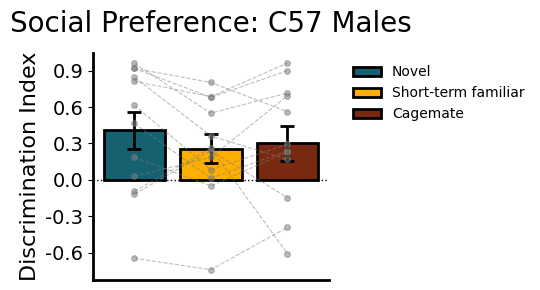